Imports

In [1]:

import gymnasium as gym
from stable_baselines3 import A2C,PPO,SAC, TD3, DDPG
import five_bar
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import mediapy as media
import pandas as pd
import sympy as sp
import time
import mujoco as mj
from PIL import Image

plt.rcParams.update({
    "text.usetex": False,  # Use LaTeX for all text (if available)
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.autolayout": True
})


In [2]:
data_folder = os.path.abspath("data")


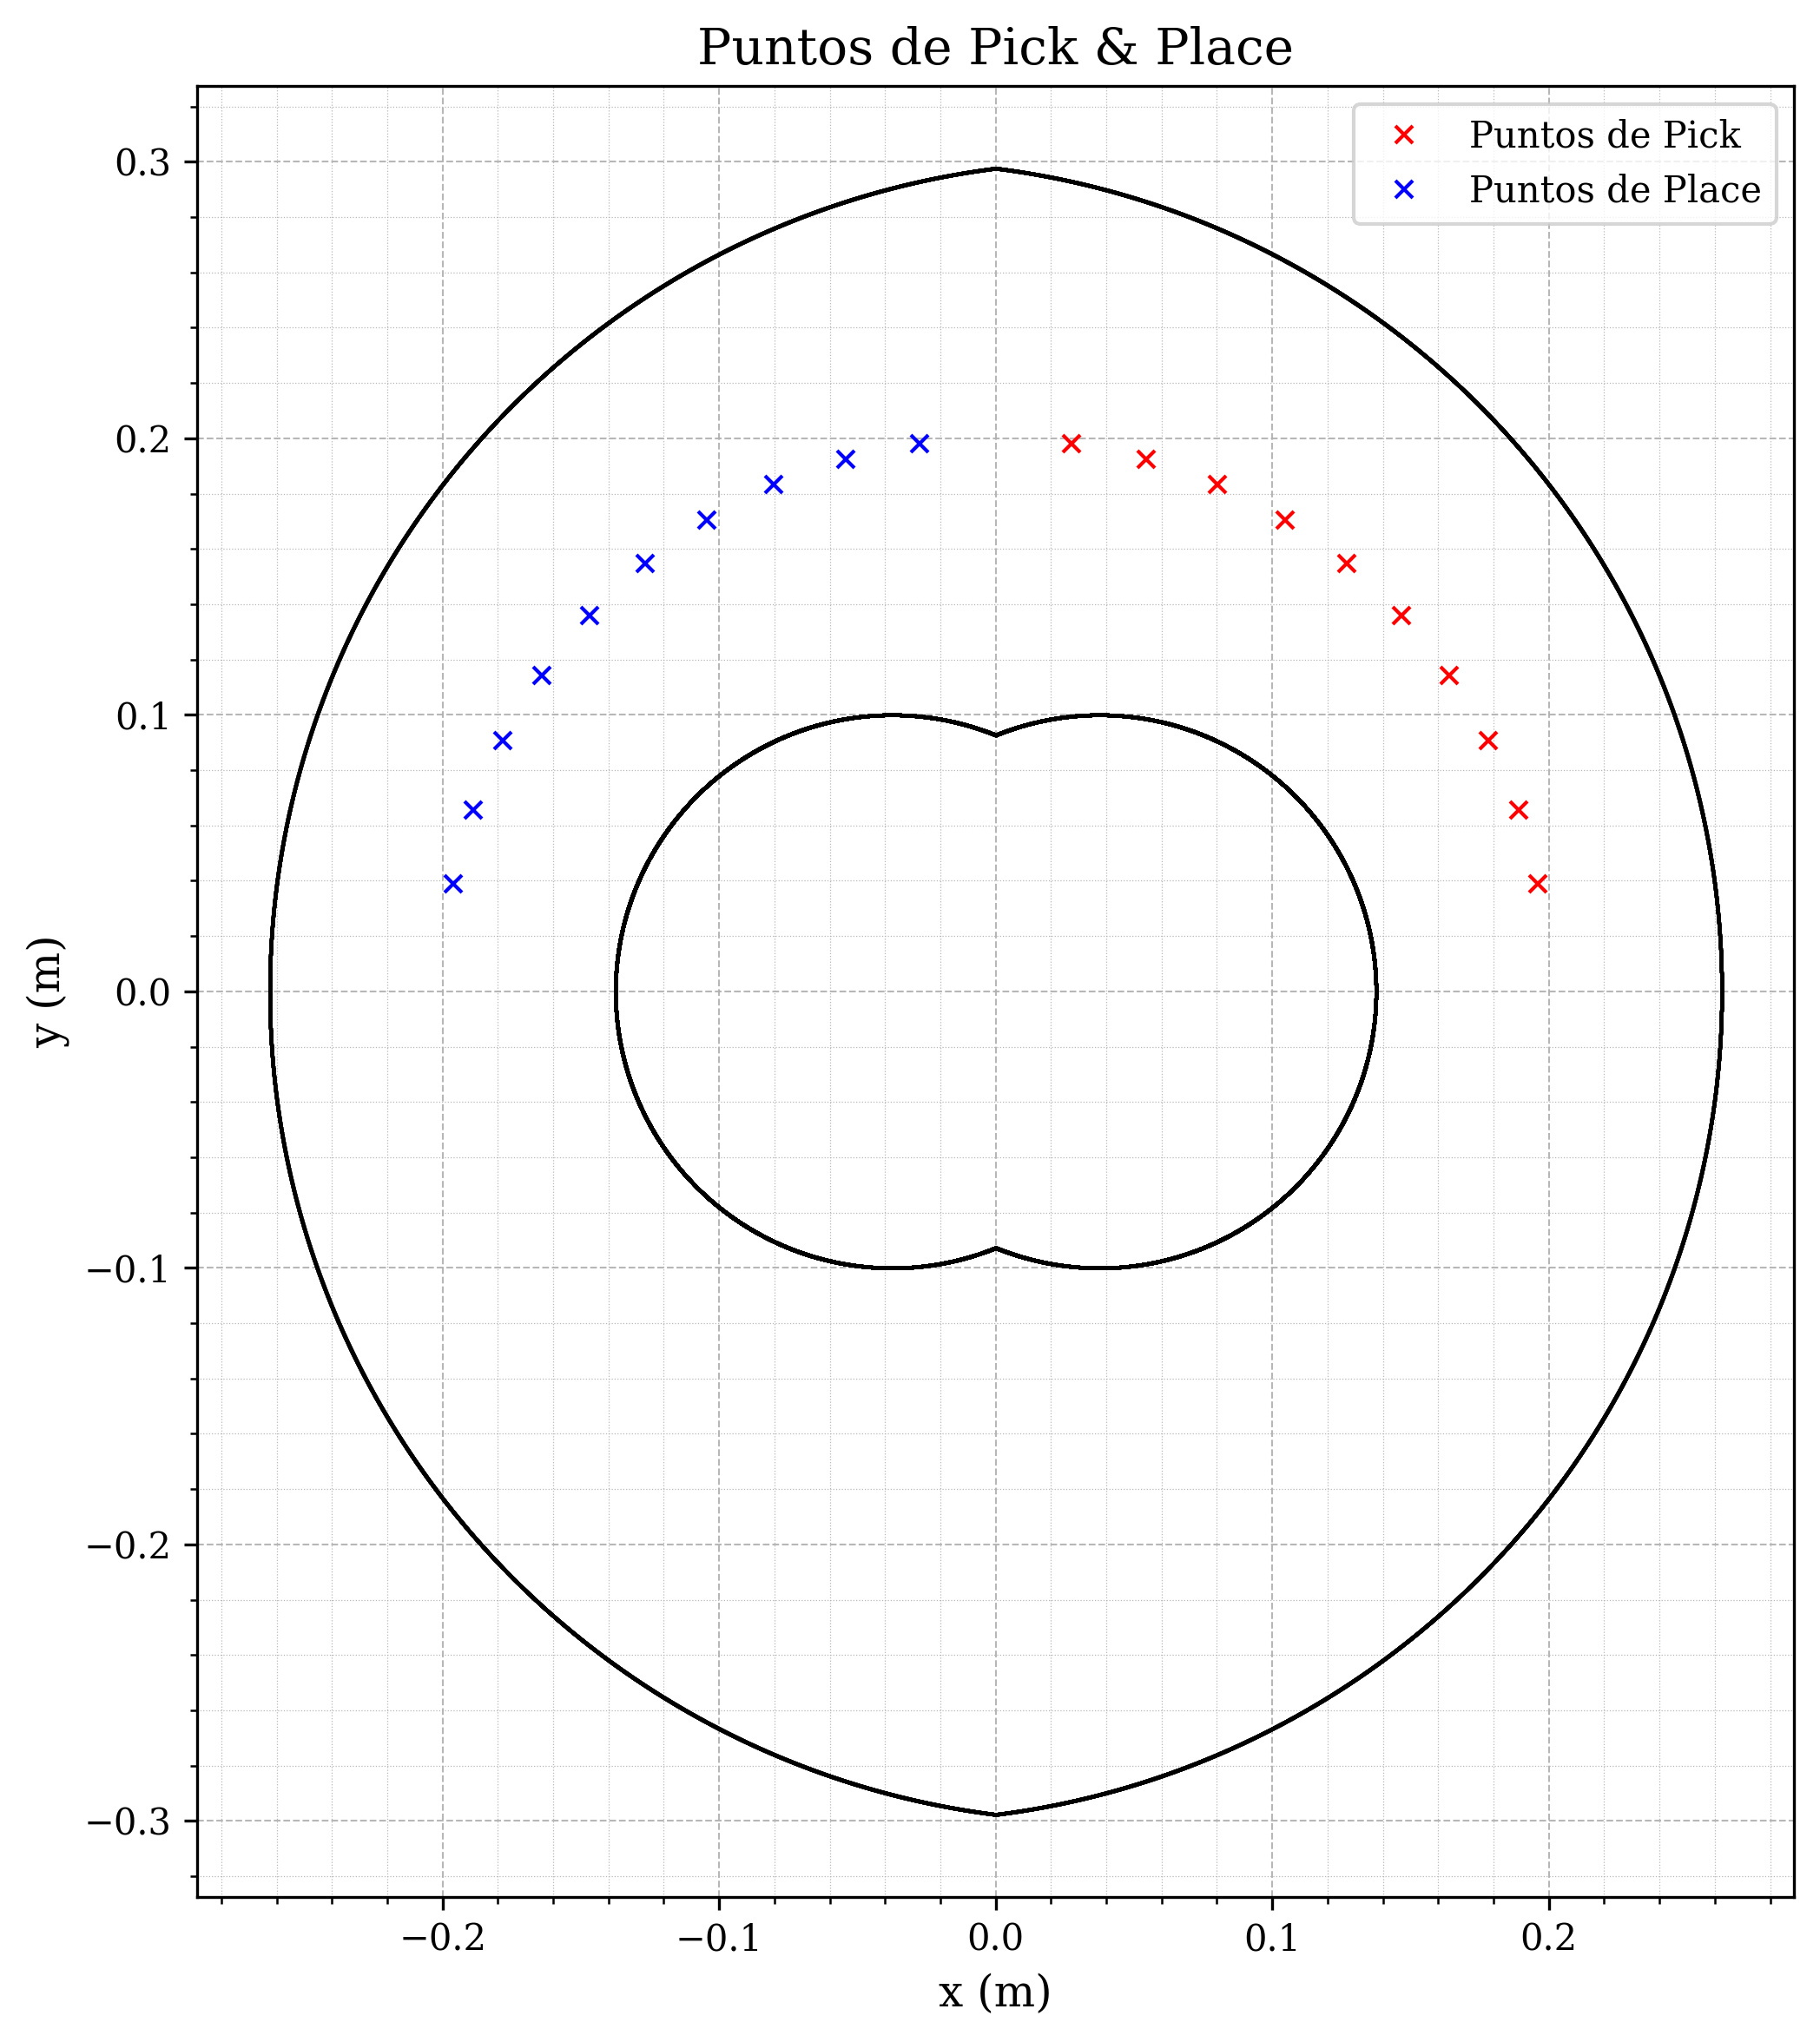

[[[np.float64(0.0274024683363936), np.float64(0.19811386808871545)], [np.float64(-0.0274024683363936), np.float64(0.19811386808871545)]], [[np.float64(0.05428808997301487), np.float64(0.19249104729072947)], [np.float64(-0.05428808997301487), np.float64(0.19249104729072947)]], [[np.float64(0.08014976662062823), np.float64(0.1832375914234272)], [np.float64(-0.08014976662062823), np.float64(0.1832375914234272)]], [[np.float64(0.10449971294318978), np.float64(0.17052803287081844)], [np.float64(-0.10449971294318978), np.float64(0.17052803287081844)]], [[np.float64(0.12687865683272911), np.float64(0.15460209067254738)], [np.float64(-0.12687865683272911), np.float64(0.15460209067254738)]], [[np.float64(0.14686450188713712), np.float64(0.13576014910658835)], [np.float64(-0.14686450188713712), np.float64(0.13576014910658835)]], [[np.float64(0.16408028870510272), np.float64(0.11435759204552245)], [np.float64(-0.16408028870510272), np.float64(0.11435759204552245)]], [[np.float64(0.178201304837673

In [3]:
pts=[]

radii=[0.2]


angles=np.linspace(np.pi/2,np.pi/16,11)
for radius in radii:
    for angle in angles[1:]:
        pts.append([[radius*np.cos(angle),radius*np.sin(angle)],[-radius*np.cos(angle),radius*np.sin(angle)]])
    
def plot_half_ellipse(ax, xc, yc, a, b, x_filter, color, linestyle='--', label=None):
    theta = np.linspace(0, 2*np.pi, 100000)
    x = xc + a * np.cos(theta)
    y = yc + b * np.sin(theta)
    
    if x_filter == '>0':
        mask = x > 0
    elif x_filter == '<0':
        mask = x < 0
    else:
        raise ValueError("x_filter must be '>0' or '<0'")
    
    ax.plot(x[mask], y[mask], color=color, marker="*",linestyle='' ,markersize=0.01,label=label)

# Create plot
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect('equal')

# Plot ellipses with original parameters
# Outer (x > 0)
plot_half_ellipse(ax, xc=-0.0375, yc=0.0, a=0.3, b=0.3, x_filter='>0', color='black')
# Inner (x > 0)
plot_half_ellipse(ax, xc=0.0375, yc=0.0, a=0.1, b=0.1, x_filter='>0', color='black')

# Outer (x < 0)
plot_half_ellipse(ax, xc=0.0375, yc=0.0, a=0.3, b=0.3, x_filter='<0', color='black')
# Inner (x < 0)
plot_half_ellipse(ax, xc=-0.0375, yc=0.0, a=0.1, b=0.1, x_filter='<0', color='black')

i=0
for pt in pts:
    if i==0:
        ax.plot(*pt[0],color='red', marker="x",linestyle='' ,markersize=5,label='Puntos de Pick')
        ax.plot(*pt[1],color='blue', marker="x",linestyle='' ,markersize=5,label='Puntos de Place')
        i+=1
    else:
        ax.plot(*pt[0],color='red', marker="x",linestyle='' ,markersize=5)
        ax.plot(*pt[1],color='blue', marker="x",linestyle='' ,markersize=5)
# Format plot

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Puntos de Pick & Place')
ax.grid(True)

ax.minorticks_on()
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.9)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.9)
ax.legend()
plt.show()
print(pts)

In [4]:
INIT_DATA_PATH=os.path.join(os.path.dirname(os.path.abspath("")),"dynamic analysis",'data','initial_pts.parquet')
XML_PATH=os.path.join(os.path.dirname(os.path.abspath("")),"assets",'5_bar_realistic.xml')


In [5]:
df_inits=pd.read_parquet(INIT_DATA_PATH)
initpts_head=df_inits.sample(5)

In [6]:
# Dynamics

# Parameters
scale = 0.5

# Motor coordinates
O_1x, O_2x,O_1y, O_2y = -0.075 * scale, 0.075 * scale,0 * scale, 0 * scale

# Link lengths
L_p1, L_p2, L_d1, L_d2 = [0.2 * scale, 0.2 * scale, 0.4 * scale, 0.4 * scale]

# A known configuration for the mechanism
q_base=np.vstack([-0.14571*scale,0.07071*scale,np.deg2rad(135),
     -0.10821*scale,0.30962*scale,np.deg2rad(57.244623466),
     0.10821*scale,0.30962*scale,np.deg2rad(-57.244623466),
     0.14571*scale,0.07071*scale,np.deg2rad(-135)])

# Symbolic variables
t = sp.Symbol('t')

phi_p1, phi_p2, phi_d1, phi_d2 = sp.symbols('phi_p1 phi_p2 phi_d1 phi_d2')
x_p1, y_p1, x_p2, y_p2 = sp.symbols('x_p1 y_p1 x_p2 y_p2')
x_d1, y_d1, x_d2, y_d2 = sp.symbols('x_d1 y_d1 x_d2 y_d2')

dphi_p1, dphi_p2, dphi_d1, dphi_d2 = sp.symbols('dphi_p1 dphi_p2 dphi_d1 dphi_d2')
dx_p1, dy_p1, dx_p2, dy_p2 = sp.symbols('dx_p1 dy_p1 dx_p2 dy_p2')
dx_d1, dy_d1, dx_d2, dy_d2 = sp.symbols('dx_d1 dy_d1 dx_d2 dy_d2')


# Rotation matrix function (symbolic and numeric)
def rotmat(phi):
    return sp.Matrix([[sp.cos(phi), -sp.sin(phi)], [sp.sin(phi), sp.cos(phi)]])

def rotmat_num(phi):
    return np.array([[np.cos(phi), -np.sin(phi)], [np.sin(phi), np.cos(phi)]])

# Generalized coordinates vector
q = sp.Matrix([x_p1, y_p1, phi_p1, x_d1, y_d1, phi_d1, x_d2, y_d2, phi_d2, x_p2, y_p2, phi_p2])
dq = sp.Matrix([dx_p1, dy_p1, dphi_p1, dx_d1, dy_d1, dphi_d1, dx_d2, dy_d2, dphi_d2, dx_p2, dy_p2, dphi_p2])

# Number of generalized coordinates
nq=len(q)

# The inverse is defined as a symolic variable to avoid the analytical calculation of the inverse of the jacobian
inv_PHI_q=sp.MatrixSymbol('inv_PHI_q', nq, nq)

# Joint equations

# Proximal link 1 - Ground
eq1 = sp.Matrix([x_p1, y_p1]) + rotmat(phi_p1) * sp.Matrix([-L_p1 / 2, 0]) - sp.Matrix([O_1x, O_1y])

# Proximal link 1 - Distal Link 1
eq2 = sp.Matrix([x_p1, y_p1]) + rotmat(phi_p1) * sp.Matrix([L_p1 / 2, 0]) - (sp.Matrix([x_d1, y_d1]) + rotmat(phi_d1) * sp.Matrix([-L_d1 / 2, 0]))

#  Proximal link 1 - Distal Link 1
eq3 = sp.Matrix([x_d1, y_d1]) + rotmat(phi_d1) * sp.Matrix([L_d1 / 2, 0]) - (sp.Matrix([x_d2, y_d2]) + rotmat(phi_d2) * sp.Matrix([-L_d2 / 2, 0]))

# Distal Link 2 - Proximal Link 2
eq4 = sp.Matrix([x_d2, y_d2]) + rotmat(phi_d2) * sp.Matrix([L_d2 / 2, 0]) - (sp.Matrix([x_p2, y_p2]) + rotmat(phi_p2) * sp.Matrix([-L_p2 / 2, 0]))

# Proximal Link 2 - Ground
eq5 = sp.Matrix([x_p2, y_p2]) + rotmat(phi_p2) * sp.Matrix([L_p2 / 2, 0]) - sp.Matrix([O_2x, O_2y])


# Time-dependent symbolic variables
sym_phi_p1 = sp.Function('sym_phi_p1')(t)
sym_phi_p2 = sp.Function('sym_phi_p2')(t)
sym_phi_p1_dot, sym_phi_p2_dot = sp.symbols('sym_phi_p1_dot sym_phi_p2_dot')
sym_phi_p1_dotdot, sym_phi_p2_dotdot = sp.symbols('sym_phi_p1_dotdot sym_phi_p2_dotdot')

# Actuaction Equations
eq6_direct = sp.Matrix([phi_p1, phi_p2]) - sp.Matrix([sym_phi_p1, sym_phi_p2])

# Constraint vector
PHI_direct = sp.simplify(sp.Matrix.vstack(eq1, eq2, eq3, eq4, eq5, eq6_direct))

# Calculates Jacobian
PHI_q_direct = PHI_direct.jacobian(q)

#Calculates first derivative
dq_eq_direct=-inv_PHI_q@PHI_direct.diff(t)

#Calculates second derivative
ddq_eq_direct=-inv_PHI_q@(((PHI_q_direct@dq).jacobian(q))@dq+2*PHI_q_direct.diff(t)@dq+PHI_direct.diff(t, t))

dq_eq_subs_direct = dq_eq_direct.subs({
    sp.Derivative(sym_phi_p1, t): sym_phi_p1_dot,
    sp.Derivative(sym_phi_p2, t): sym_phi_p2_dot
})

ddq_eq_subs_direct = ddq_eq_direct.subs({
    sp.Derivative(sym_phi_p1, t): sym_phi_p1_dot,
    sp.Derivative(sym_phi_p2, t): sym_phi_p2_dot,
    sp.Derivative(sp.Derivative(sym_phi_p1, t),t): sym_phi_p1_dotdot,
    sp.Derivative(sp.Derivative(sym_phi_p2, t),t): sym_phi_p2_dotdot
})

# Convert symbolic expressions to numerical functions
PHI_fun_direct = sp.lambdify((q, sym_phi_p1,sym_phi_p2), PHI_direct, 'numpy')
PHI_q_fun_direct = sp.lambdify((q, sym_phi_p1,sym_phi_p2), PHI_q_direct, 'numpy')

dq_fun_direct = sp.lambdify((q, inv_PHI_q, sym_phi_p1_dot, sym_phi_p2_dot), dq_eq_subs_direct, 'numpy')
ddq_fun_direct= sp.lambdify((q,dq, inv_PHI_q, sym_phi_p1_dot, sym_phi_p2_dot,sym_phi_p1_dotdot,sym_phi_p2_dotdot), ddq_eq_subs_direct, 'numpy')


def direct_kinematics(q_0,phi_p1_val,phi_p2_val,dphi_p1_val,dphi_p2_val,ddphi_p1_val,ddphi_p2_val):
    # Newton - Rhapson Solver Parameters
    tol=1e-6
    max_iters=100
 
    j=1 # Reset iteration counter
    q_0=np.vstack(q_0) # Use random solution as the initial guess for the next iteration
    
    while True:

        phi_val=PHI_fun_direct(q_0.flatten(),phi_p1_val,phi_p2_val)
        
        phi_q_val=PHI_q_fun_direct(q_0.flatten(),phi_p1_val,phi_p2_val)
        
        inv_phi_q_val=np.linalg.inv(phi_q_val)
        
        q_1=q_0-inv_phi_q_val@phi_val
        
        if j>max_iters:
            return None
        
        if max(abs(phi_val))<=tol:
            
            q_sol=q_0.flatten()
            
            dq_sol = dq_fun_direct(q_sol, inv_phi_q_val, dphi_p1_val, dphi_p2_val).flatten()
            
            ddq_sol = ddq_fun_direct(q_sol,dq_sol, inv_phi_q_val, dphi_p1_val, dphi_p2_val,ddphi_p1_val,ddphi_p2_val).flatten()
            
            return q_sol,dq_sol,ddq_sol,phi_q_val
        q_0=q_1
        j+=1

# Time-dependent symbolic variables
sym_effx = sp.Function('sym_effx')(t)
sym_effy = sp.Function('sym_effy')(t)
sym_effx_dot, sym_effy_dot = sp.symbols('sym_effx_dot sym_effy_dot')
sym_effx_dotdot, sym_effy_dotdot = sp.symbols('sym_effx_dotdot sym_effy_dotdot')

# Actuaction Equations
eq6_inverse = sp.Matrix([sym_effx, sym_effy])-sp.Matrix([x_d1, y_d1]) - rotmat(phi_d1) * sp.Matrix([L_d1 / 2, 0])

# Constraint vector
PHI_inverse = sp.simplify(sp.Matrix.vstack(eq1, eq2, eq3, eq4, eq5, eq6_inverse))

# Calculates Jacobian
PHI_q_inverse = PHI_inverse.jacobian(q)

#Calculates first derivative
dq_eq_inverse=-inv_PHI_q@PHI_inverse.diff(t)

#Calculates second derivative
ddq_eq_inverse=-inv_PHI_q@(((PHI_q_inverse@dq).jacobian(q))@dq+2*PHI_q_inverse.diff(t)@dq+PHI_inverse.diff(t, t))

dq_eq_subs_inverse = dq_eq_inverse.subs({
    sp.Derivative(sym_effx, t): sym_effx_dot,
    sp.Derivative(sym_effy, t): sym_effy_dot
})

ddq_eq_subs_inverse = ddq_eq_inverse.subs({
    sp.Derivative(sym_effx, t): sym_effx_dot,
    sp.Derivative(sym_effy, t): sym_effy_dot,
    sp.Derivative(sp.Derivative(sym_effx, t),t): sym_effx_dotdot,
    sp.Derivative(sp.Derivative(sym_effy, t),t): sym_effy_dotdot
})

# Convert symbolic expressions to numerical functions
PHI_fun_inverse = sp.lambdify((q, sym_effx,sym_effy), PHI_inverse, 'numpy')
PHI_q_fun_inverse = sp.lambdify((q, sym_effx,sym_effy), PHI_q_inverse, 'numpy')

dq_fun_inverse = sp.lambdify((q, inv_PHI_q, sym_effx_dot, sym_effy_dot), dq_eq_subs_inverse, 'numpy')
ddq_fun_inverse= sp.lambdify((q,dq, inv_PHI_q, sym_effx_dot, sym_effy_dot,sym_effx_dotdot,sym_effy_dotdot), ddq_eq_subs_inverse, 'numpy')


def inverse_kinematics(q_0,effx_val,effy_val,deffx_val,deffy_val,ddeffx_val,ddeffy_val):
    # Newton - Rhapson Solver Parameters
    tol=1e-6
    max_iters=100
 
    j=1 # Reset iteration counter
    q_0=np.vstack(q_0) # Use random solution as the initial guess for the next iteration
    
    while True:

        phi_val=PHI_fun_inverse(q_0.flatten(),effx_val,effy_val)
        
        phi_q_val=PHI_q_fun_inverse(q_0.flatten(),effx_val,effy_val)
        
        inv_phi_q_val=np.linalg.inv(phi_q_val)
        
        q_1=q_0-inv_phi_q_val@phi_val
        
        if j>max_iters:
            return None
        
        if max(abs(phi_val))<=tol:
            
            q_sol=q_0.flatten()
            
            dq_sol = dq_fun_inverse(q_sol, inv_phi_q_val, deffx_val, deffy_val).flatten()
            
            ddq_sol = ddq_fun_inverse(q_sol,dq_sol, inv_phi_q_val, deffx_val, deffy_val,ddeffx_val,ddeffy_val).flatten()
            
            return q_sol,dq_sol,ddq_sol,phi_q_val
        q_0=q_1
        j+=1

In [347]:
#q_sol,dq_sol,ddq_sol,phi_q_val=inverse_kinematics(q_0,effx_val,effy_val,deffx_val,deffy_val,ddeffx_val,ddeffy_val)
#q_sol,dq_sol,ddq_sol,phi_q_val=direct_kinematics(q_0,phi_p1_val,phi_p2_val,dphi_p1_val,dphi_p2_val,ddphi_p1_val,ddphi_p2_val)

In [7]:
#polynomials
def quintic_trajectory(T,theta_i, theta_f, speed_i=0, speed_f=0, acceleration_i=0, acceleration_f=0):
    """
    Returns the coefficients [a0, a1, a2, a3, a4, a5] of the quintic polynomial:
    θ(t) = a0 + a1*t + a2*t^2 + a3*t^3 + a4*t^4 + a5*t^5
    that interpolates position, velocity, and acceleration at t=0 and t=T.
    """
    a0 = theta_i
    a1 = speed_i
    a2 = acceleration_i / 2

    # Setup linear system for [a3, a4, a5]
    A = np.array([
        [T**3,    T**4,     T**5],
        [3*T**2,  4*T**3,   5*T**4],
        [6*T,     12*T**2,  20*T**3]
    ])
    B = np.array([
        theta_f - (a0 + a1*T + a2*T**2),
        speed_f - (a1 + 2*a2*T),
        acceleration_f - (2*a2)
    ])

    a3, a4, a5 = np.linalg.solve(A, B)

    return [a0, a1, a2, a3, a4, a5]

def evaluate_quintic(coeffs, t, T):
    """
    Evaluates θ(t), θ̇(t), and θ̈(t) for a quintic polynomial:
    θ(t) = a0 + a1*t + a2*t^2 + a3*t^3 + a4*t^4 + a5*t^5

    Args:
        coeffs (list): Coefficients [a0, a1, a2, a3, a4, a5] of the quintic polynomial.
        t (float): Time at which to evaluate.
        T (float): Total duration, used to clamp t between 0 and T.

    Returns:
        list: [θ(t), θ̇(t), θ̈(t)]
    """
    a0, a1, a2, a3, a4, a5 = coeffs
    
    t = max(0, min(t, T))  # Clamp t to [0, T]

    theta = a0 + a1*t + a2*t**2 + a3*t**3 + a4*t**4 + a5*t**5
    theta_dot = a1 + 2*a2*t + 3*a3*t**2 + 4*a4*t**3 + 5*a5*t**4
    theta_dotdot = 2*a2 + 6*a3*t + 12*a4*t**2 + 20*a5*t**3

    return theta, theta_dot, theta_dotdot

In [8]:
model=mj.MjModel.from_xml_path(XML_PATH)
data = mj.MjData(model)

scene_option = mj.MjvOption()
cam = mj.MjvCamera()
cam.type = mj.mjtCamera.mjCAMERA_FREE
cam.fixedcamid = -1  # Free camera mode
cam.distance = 0.75   # Distance from lookat point
cam.azimuth = 90      # Rotation around vertical axis (0 for straight)
cam.elevation = -90  # -90 looks straight down
cam.lookat = np.array([0.0, 0.0, 0.0])

In [14]:
#q_sol,dq_sol,ddq_sol,phi_q_val=inverse_kinematics(q_0,effx_val,effy_val,deffx_val,deffy_val,ddeffx_val,ddeffy_val)
#q_sol,dq_sol,ddq_sol,phi_q_val=direct_kinematics(q_0,phi_p1_val,phi_p2_val,dphi_p1_val,dphi_p2_val,ddphi_p1_val,ddphi_p2_val)
# [a0, a1, a2, a3, a4, a5]=quintic_trajectory(T,theta_i, theta_f, speed_i=0, speed_f=0, acceleration_i=0, acceleration_f=0)
# [theta, theta_dot, theta_dotdot]=evaluate_quintic(coeffs, t, T)
q_pick,_,_,_=inverse_kinematics(q_base,0.1,0.2,0,0,0,0)
q_place,_,_,_=inverse_kinematics(q_base,-0.1,0.2,0,0,0,0)

Import RL agent

In [33]:
RL_model_names=["sac_enA-9.41_diA-6.38_enB-6.95_diB-7.68","ppo_enA-9.40_diA-6.38_enB-6.95_diB-7.68","td3_enA-9.40_diA-6.38_enB-6.95_diB-7.68"]#,"sac_enA-9.40_diA-6.38_enB-6.95_diB-7.68"

In [31]:
def model_load(env,RL_model_name):
    
    algo_name=RL_model_name.split("_")[0]
        
    path=os.path.join(os.path.dirname(os.getcwd()),"RL","trained_agents",RL_model_name,"agent.zip")
    
    if algo_name.lower() == 'ddpg':
        model = DDPG.load(path, env=env)
    elif algo_name.lower() == 'ppo':
        model = PPO.load(path, env=env)
    elif algo_name.lower() == 'a2c':
        model = A2C.load(path, env=env)
    elif algo_name.lower() == 'sac':
        model = SAC.load(path, env=env)
    elif algo_name.lower() == 'td3':
        model = TD3.load(path, env=env)
    else:
        raise ValueError(f"Algorithm {algo_name} not recognized. Please choose 'ddpg', 'ppo', 'a2c', 'sac' or td3.")
    
    return model

In [48]:
data_log = []

for i in range(len(RL_model_names)):

    RL_env = gym.make("five_bar-v0")
    RL_model=model_load(RL_env,RL_model_names[i])
    duration = 9
    # total simulation time
    framerate = 60
    frames = []
    

    mj.mj_resetData(model, data)


    # Set initial pick position
    data.qpos[4] = 0.1
    data.qpos[5] = 0.2
    mj.mj_forward(model, data)
    
    q_act,_,_,_=direct_kinematics(q_base,q_pick[2],q_pick[11],0,0,0,0)
    q_est=q_act

    t_0 = 0.0
    done=False

    with mj.Renderer(model) as renderer:
        while data.time < duration:
            # === Control Step ===
            theta = [data.qpos[0], data.qpos[2]]
            omega = [data.qvel[0], data.qvel[2]]
            obs = np.concatenate([
                np.cos(theta),
                np.sin(theta),
                [data.qpos[4], data.qpos[5]],
                omega,
                [data.sensordata[0] - data.qpos[4], data.sensordata[1] - data.qpos[5]]
            ])
            action, _ = RL_model.predict(obs, deterministic=True)
            data.ctrl[0] =  1.6*action[0]
            data.ctrl[1] =  1.6*action[1]
            mj.mj_step(model, data)
            q_act,_,_,_=direct_kinematics(q_est,theta[0],theta[1],0,0,0,0)
            q_est=q_act
            
            # === Logging: only for pick→place and place→pick ===
            if data.time > 3.0:
                if not done:

                    
                    q_resetter,_,_,_=inverse_kinematics(q_est,0.1,0.2,0,0,0,0)
                    
                    q_p1=q_resetter[2]
                    q_d1=q_resetter[5]
                    q_d2=q_resetter[8]
                    q_p2=q_resetter[11]
                    
                    j1=q_p1
                    j2=q_p2
                    j3=q_d1-q_p1
                    j4=q_d2-q_p2
                    
                    data.qpos = np.array([j1,j3,j2,j4,data.qpos[4],data.qpos[5]])
                    mj.mj_forward(model, data)
                    done=True
                data_log.append({
                    'algo': RL_model_names[i].split("_")[0],
                    'time': data.time - 3,
                    'target': (data.qpos[4], data.qpos[5]),
                    'torque1': data.ctrl[0],
                    'torque2': data.ctrl[1],
                    'theta1': data.qpos[0],
                    'theta2': data.qpos[2],
                    'omega1': data.qvel[0],
                    'omega2': data.qvel[2],
                    'eff_x': data.sensordata[0],
                    'eff_y': data.sensordata[1],
                })
                if 5>data.time > 3.0:
                    data.qpos[4] = -0.1
                    data.qpos[5] = 0.2
                elif data.time > 7:
                    data.qpos[4] = 0.1
                    data.qpos[5] = 0.2

                    
                

            # === Rendering ===
            if len(frames) < data.time * framerate:
                renderer.update_scene(data, scene_option=scene_option, camera=cam)
                pixels = renderer.render()
                frames.append(pixels)

    media.show_video(frames, fps=framerate)


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


This browser does not support the video tag.


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


c:\Users\juanp\Desktop\Master-Thesis\mthesis_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


This browser does not support the video tag.


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


This browser does not support the video tag.


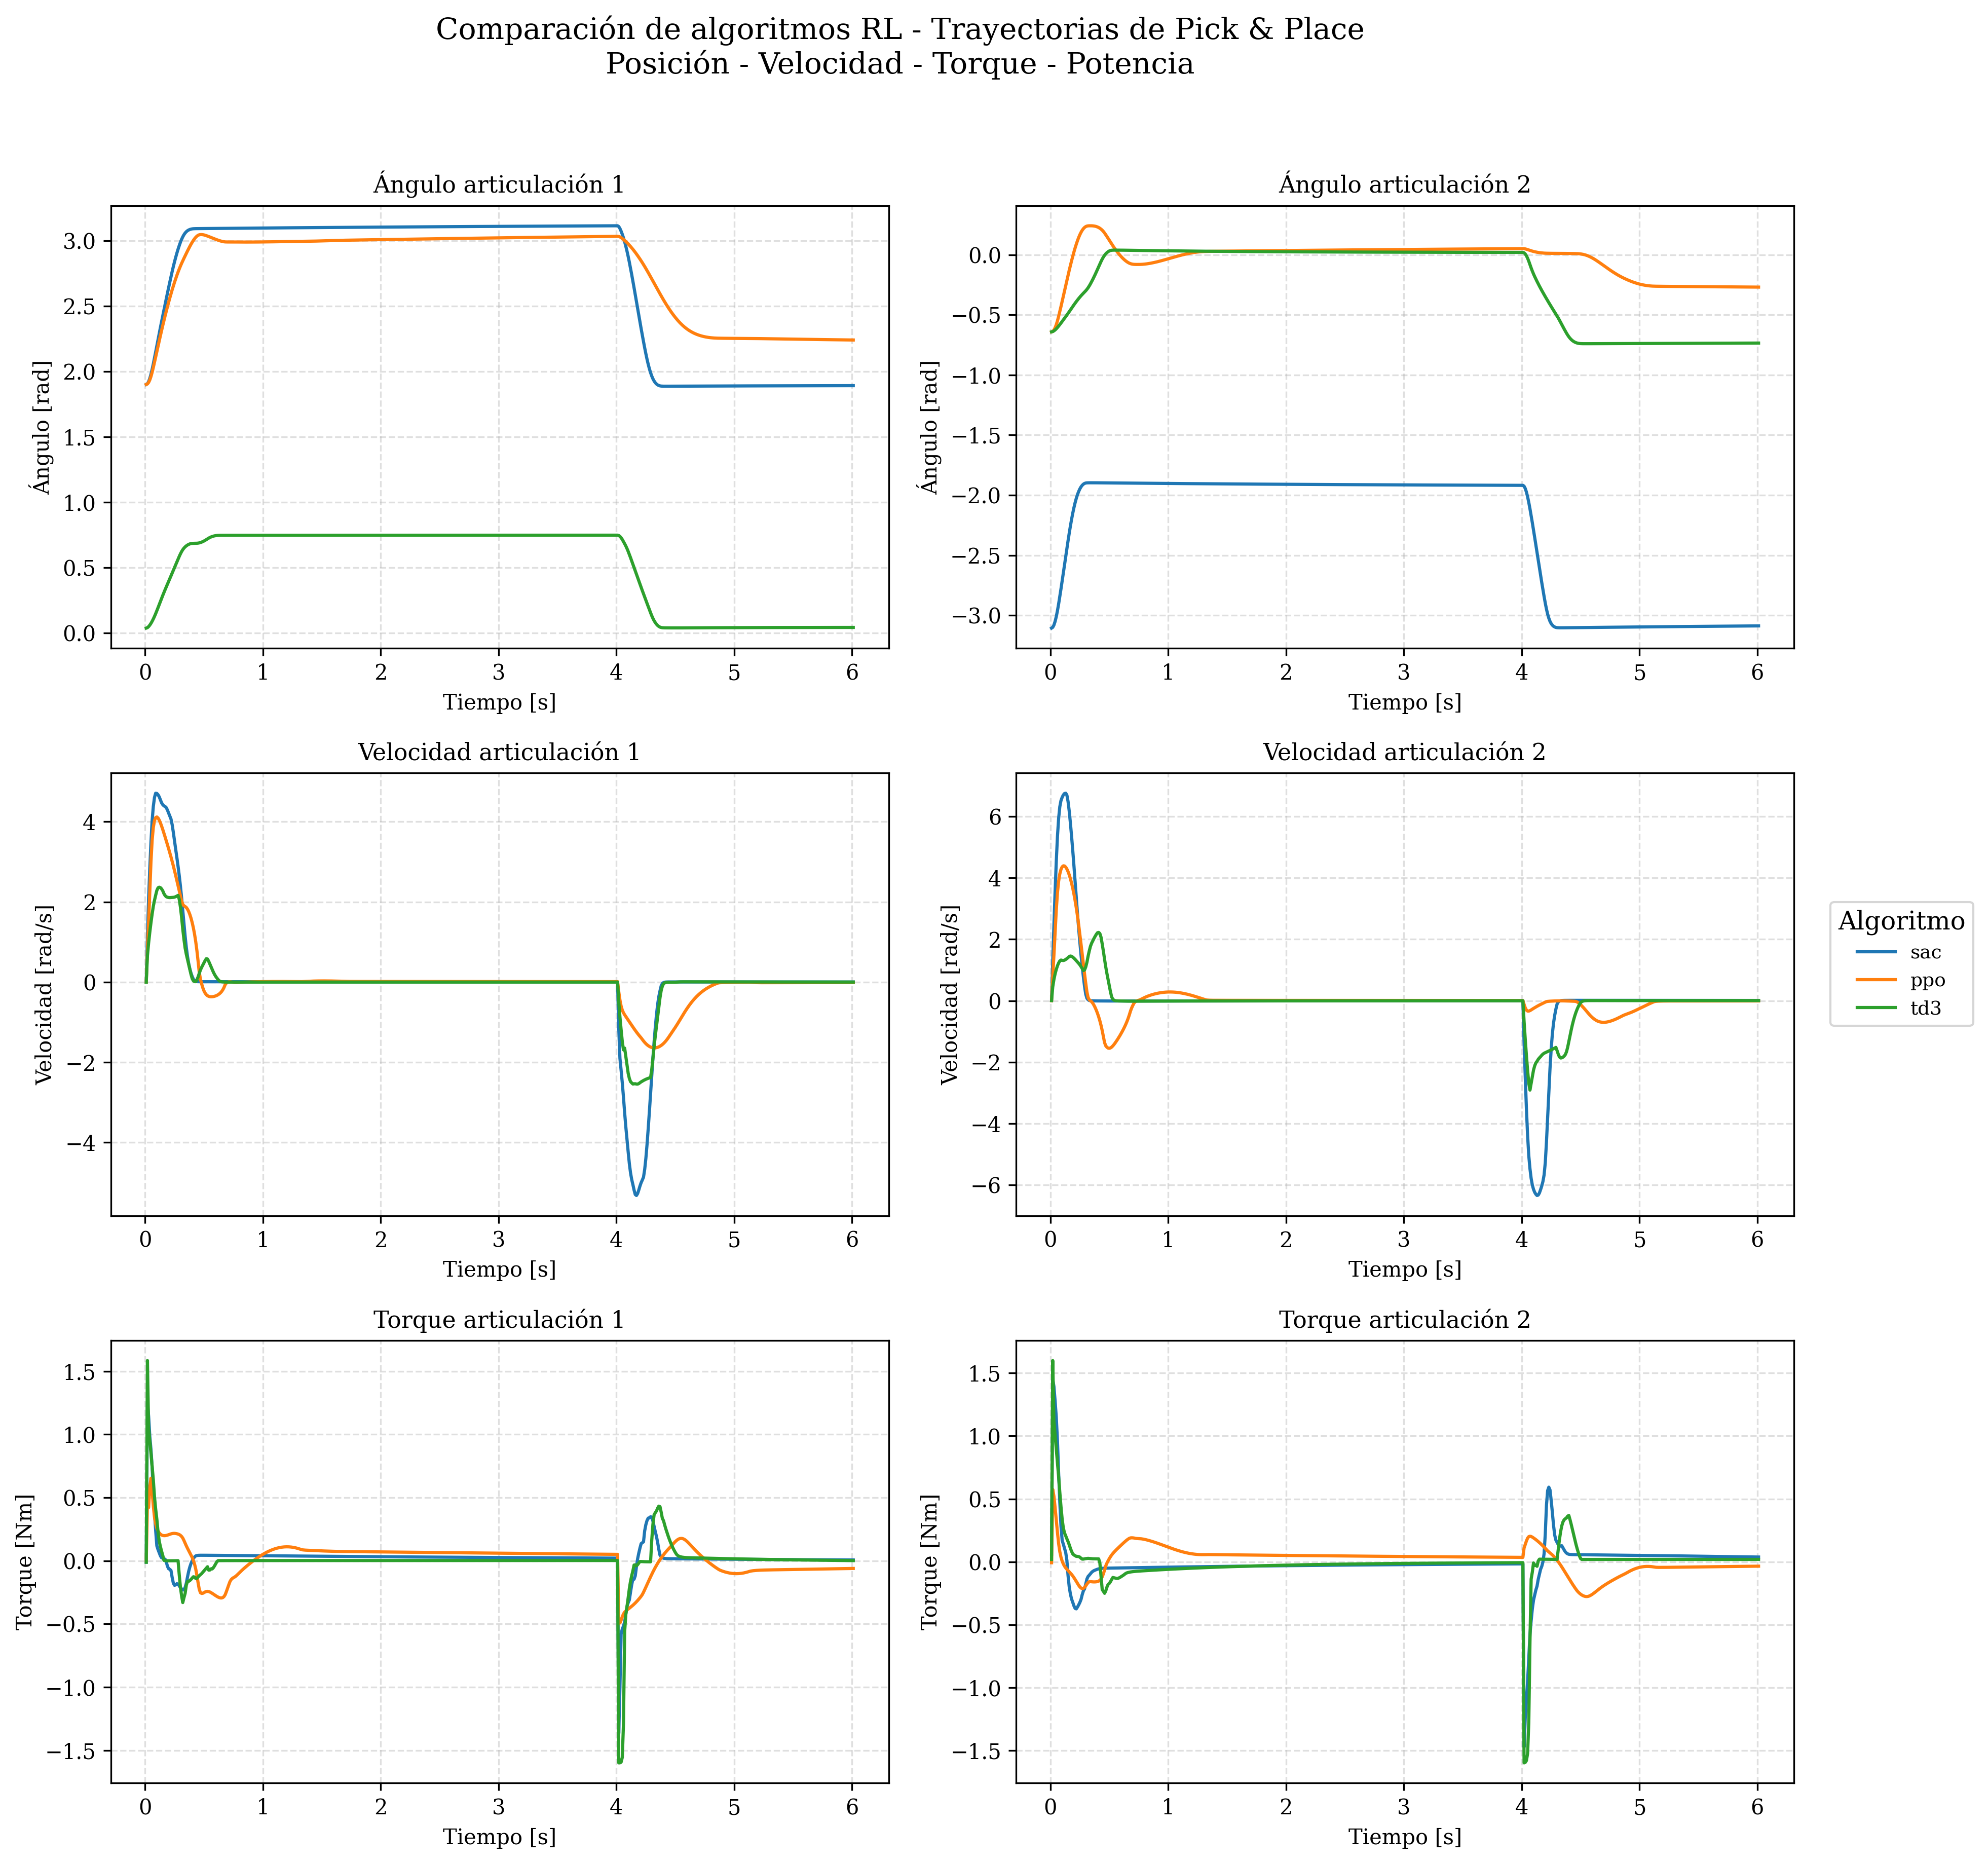

In [ ]:
# Load data
df = pd.DataFrame(data_log)  # data_log should contain data for all algos

# Compute positive power
df['power1'] = np.maximum(df['torque1'] * df['omega1'], 0)
df['power2'] = np.maximum(df['torque2'] * df['omega2'], 0)

# Set up figure: 4 rows × 2 columns
fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=False)

# Color cycle
color_map = plt.get_cmap("tab10")
legend_lines = []

# Iterate over algorithms
algos = df['algo'].unique()

for i, algo_name in enumerate(algos):
    df_algo = df[df['algo'] == algo_name].copy()
    df_algo.sort_values('time', inplace=True)  # ensure sorted

    t = df_algo['time'].values
    color = color_map(i % 10)

    # Extract signals
    theta1 = df_algo['theta1'].values
    theta2 = df_algo['theta2'].values
    omega1 = df_algo['omega1'].values
    omega2 = df_algo['omega2'].values
    torque1 = df_algo['torque1'].values
    torque2 = df_algo['torque2'].values
    power1 = df_algo['power1'].values
    power2 = df_algo['power2'].values

    # Plot each
    axes[0, 0].plot(t, theta1, color=color)
    axes[0, 1].plot(t, theta2, color=color)
    axes[1, 0].plot(t, omega1, color=color)
    axes[1, 1].plot(t, omega2, color=color)
    axes[2, 0].plot(t, torque1, color=color)
    axes[2, 1].plot(t, torque2, color=color)


    legend_lines.append(plt.Line2D([], [], color=color, label=algo_name))

# Titles and labels
titles = [["Ángulo articulación 1", "Ángulo articulación 2"],
          ["Velocidad articulación 1", "Velocidad articulación 2"],
          ["Torque articulación 1", "Torque articulación 2"],
          ["Potencia articulación 1", "Potencia articulación 2"]]

ylabels = [["Ángulo [rad]"]*2,
           ["Velocidad [rad/s]"]*2,
           ["Torque [Nm]"]*2,
           ["Potencia [W]"]*2]

for row in range(3):
    for col in range(2):
        ax = axes[row, col]
        ax.set_title(titles[row][col], fontsize=11)
        ax.set_ylabel(ylabels[row][col], fontsize=10)
        ax.set_xlabel("Tiempo [s]", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.4)

# Global legend
fig.legend(handles=legend_lines, loc='center left', bbox_to_anchor=(1.01, 0.5),
           borderaxespad=0, fontsize=9, title="Algoritmo")

plt.suptitle("Inferencia de algoritmos RL - Trayectorias de Pick & Place\nPosición - Velocidad - Torque - Potencia", fontsize=14, y=1.02)

plt.tight_layout()
plt.subplots_adjust(right=0.99)
plt.show()

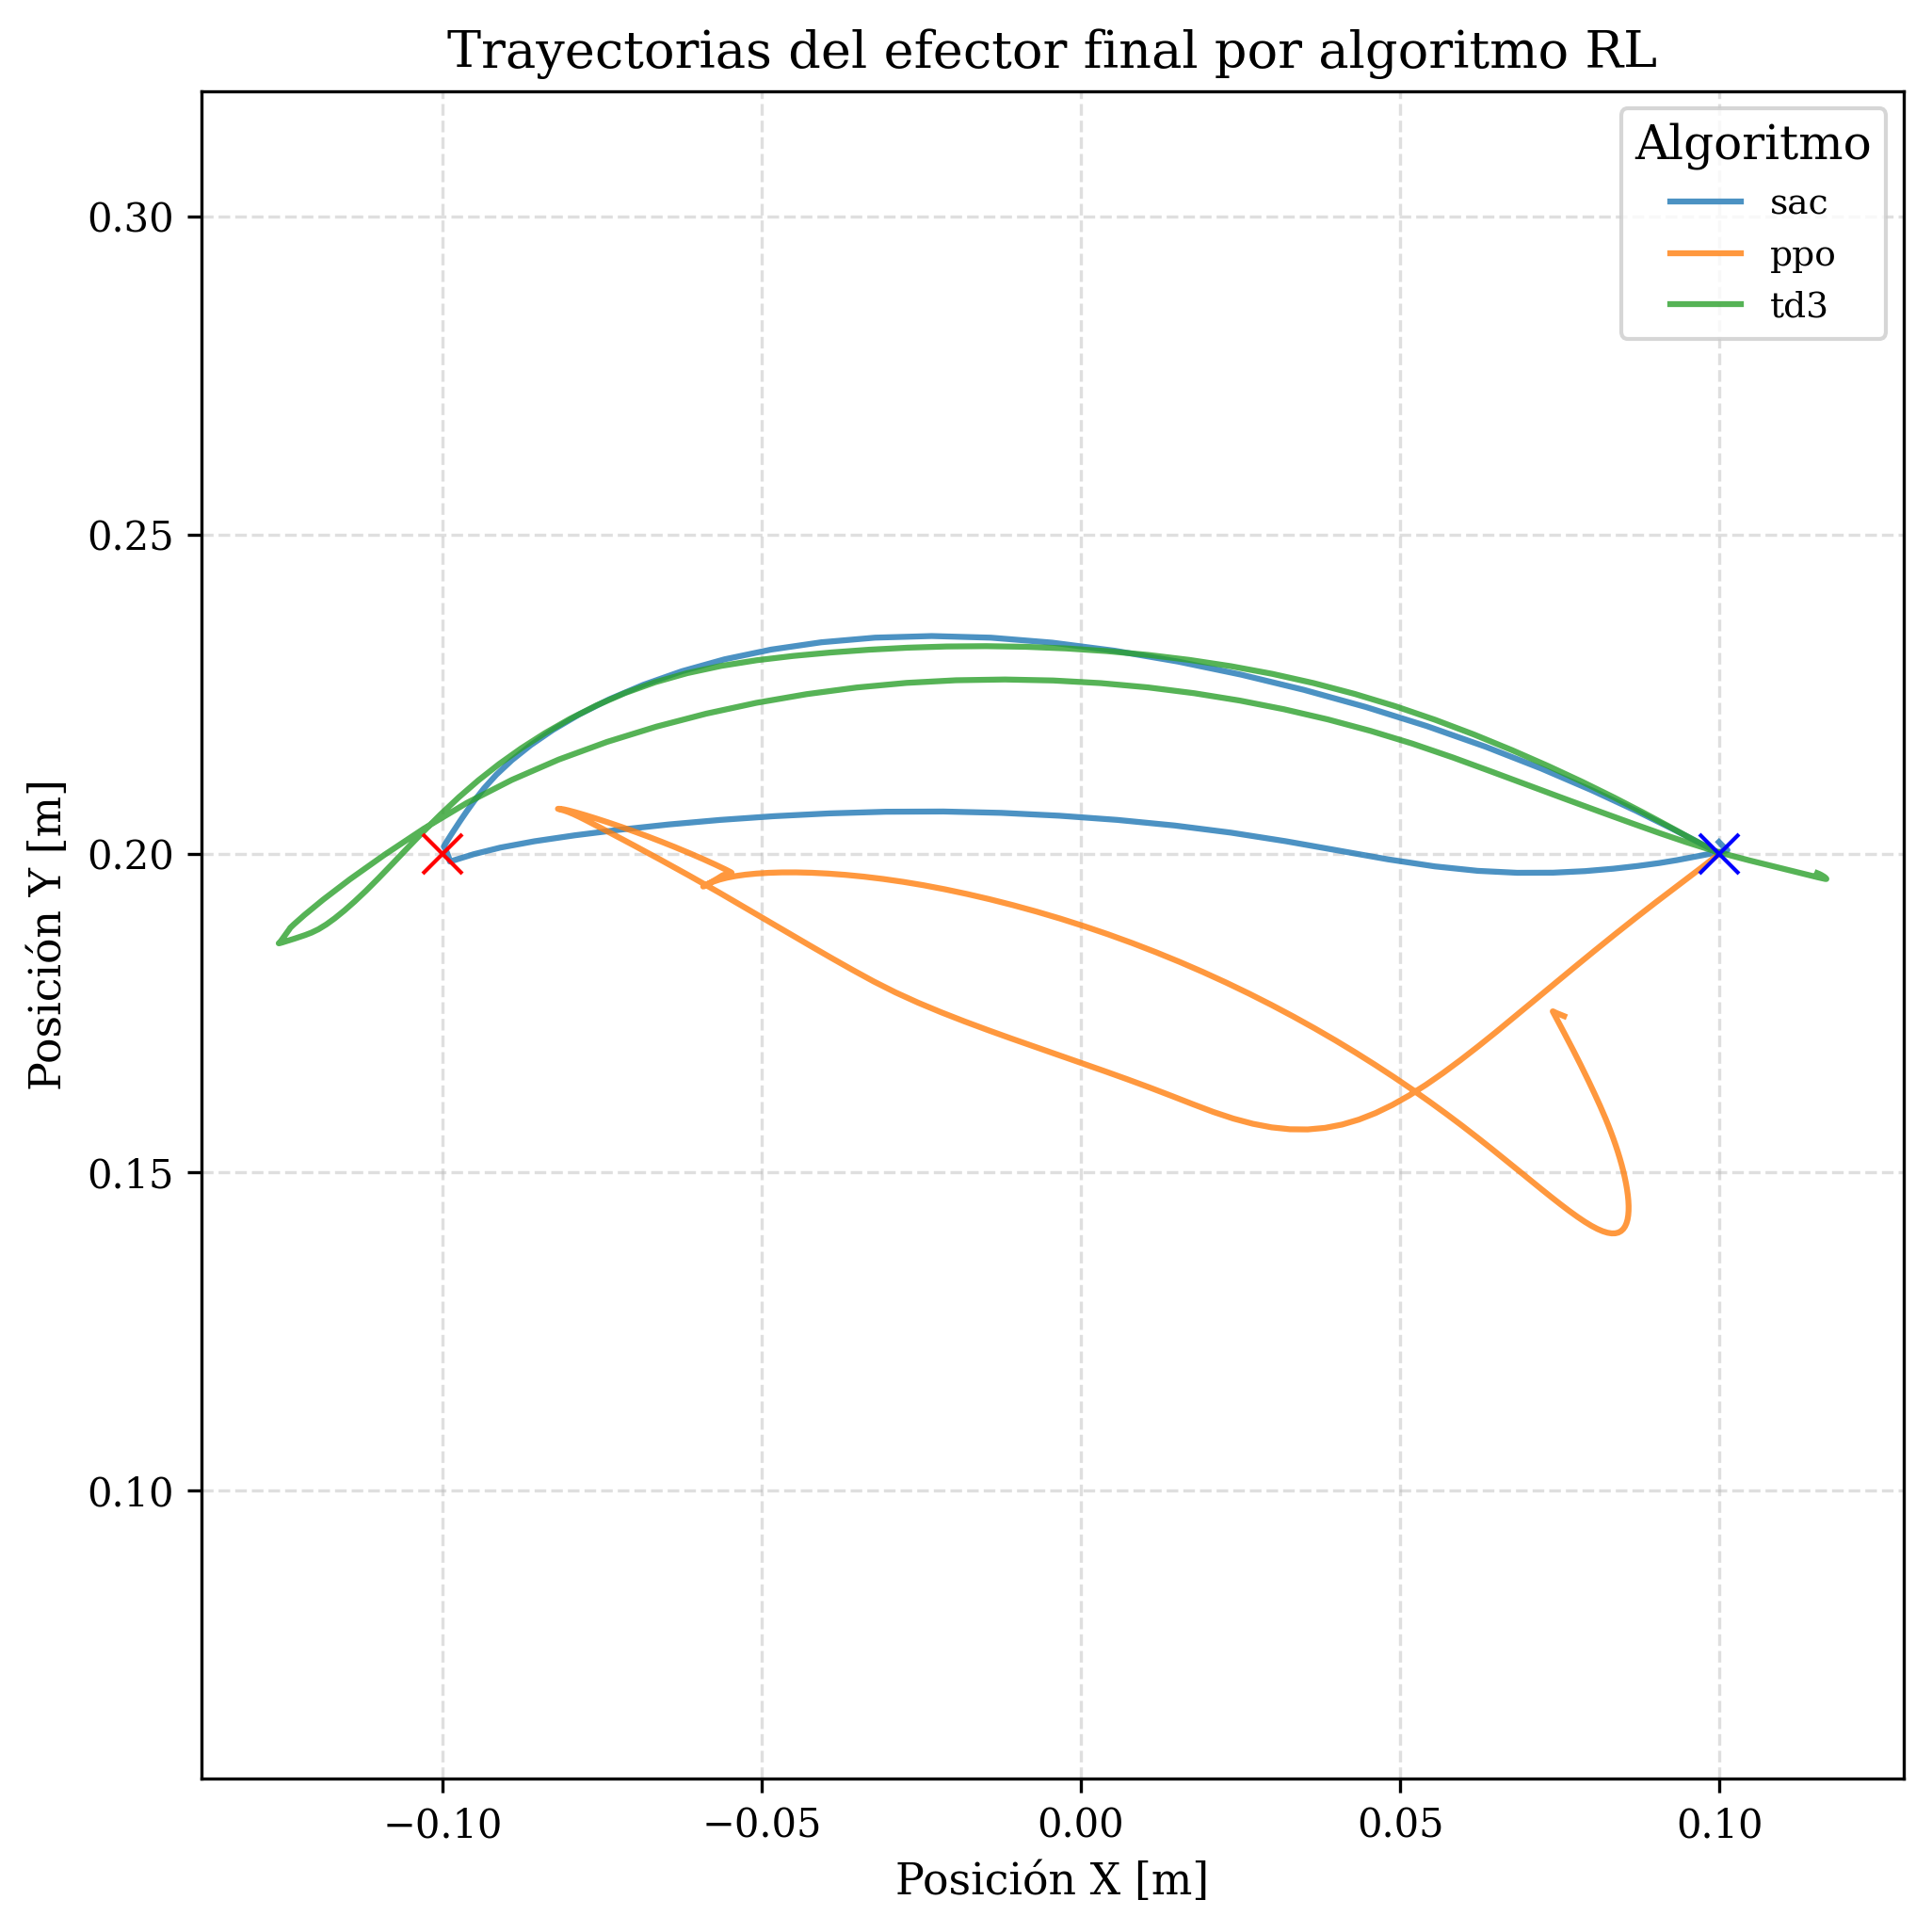

In [51]:
df_all = pd.DataFrame(data_log)  # or pd.concat([...]) if you're collecting across runs

# === Plot ===
fig, ax = plt.subplots(figsize=(7, 7))
color_map = plt.get_cmap("tab10")

for i, algo_name in enumerate(df_all['algo'].unique()):
    df_algo = df_all[df_all['algo'] == algo_name]
    ax.plot(df_algo['eff_x'], df_algo['eff_y'],
            label=algo_name,
            color=color_map(i % 10),
            alpha=0.8)

# === Formatting ===
ax.set_title("Trayectorias del efector final por algoritmo RL", fontsize=13)
ax.set_xlabel("Posición X [m]", fontsize=11)
ax.set_ylabel("Posición Y [m]", fontsize=11)
ax.axis('equal')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(title="Algoritmo", fontsize=9)
ax.plot(-0.1,0.2,marker='x',markersize=10,color='red')
ax.plot(0.1,0.2,marker='x',markersize=10,color='blue')
plt.tight_layout()
plt.show()